In [162]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression,LinearRegression
# from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [163]:
df = pd.read_csv("heart.csv")

**EDA -> Exploratory Data Analysis**

In [164]:
df.head(2)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1


In [165]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [166]:
df.shape

(918, 12)

In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [168]:
df.drop_duplicates()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [169]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [170]:
df['ChestPainType'].unique()

array(['ATA', 'NAP', 'ASY', 'TA'], dtype=object)

In [171]:
df['Cholesterol'].value_counts()

,count
Cholesterol,
0,172
254,11
220,10
223,10
204,9
...,...
353,1
278,1
157,1


In [172]:
df['RestingECG'].unique()

array(['Normal', 'ST', 'LVH'], dtype=object)

In [173]:
df['ST_Slope'].unique()

array(['Up', 'Flat', 'Down'], dtype=object)

<Axes: xlabel='Age', ylabel='Count'>

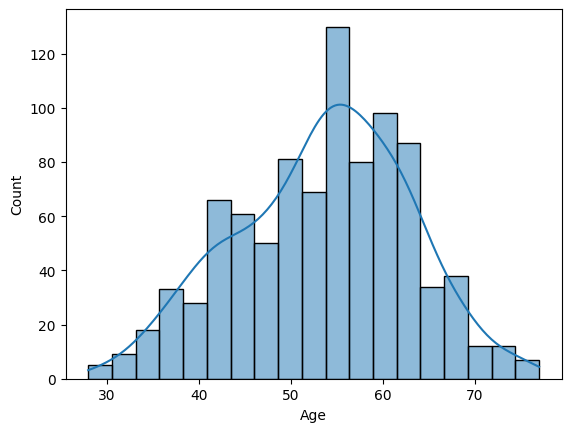

In [174]:
sns.histplot(data=df,x='Age',kde=True)

In [175]:
df_copy = df.copy()

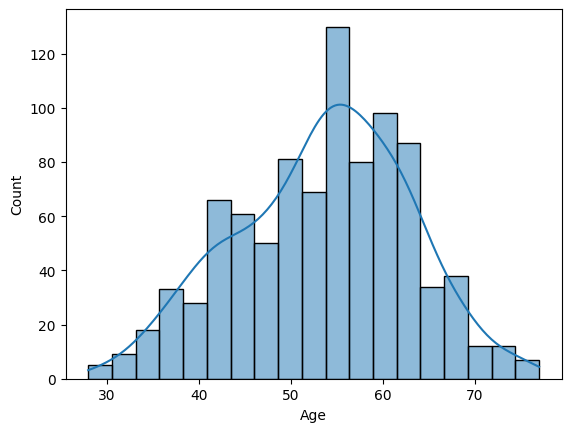

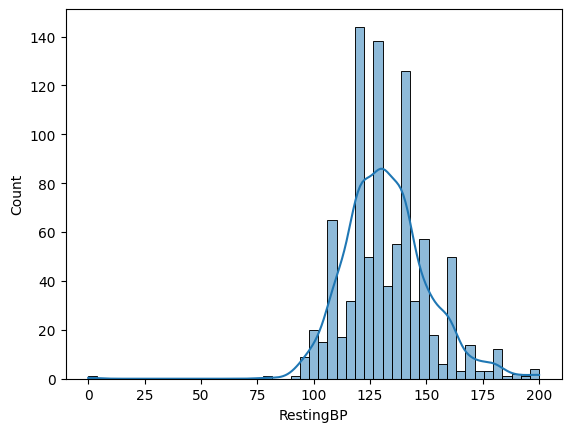

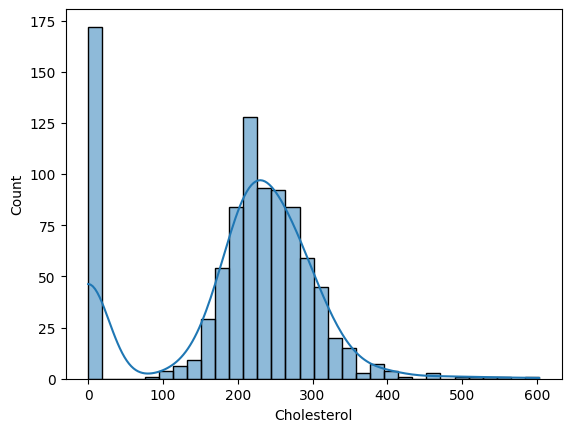

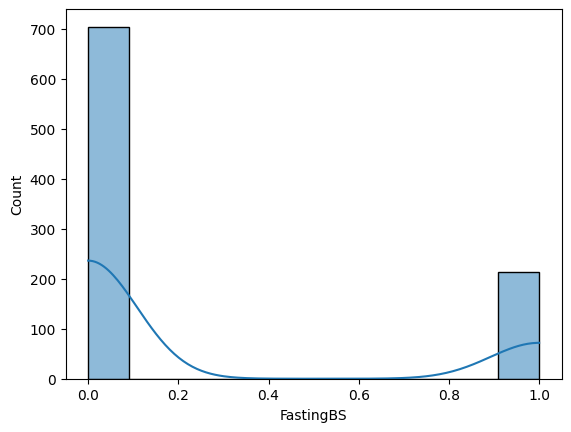

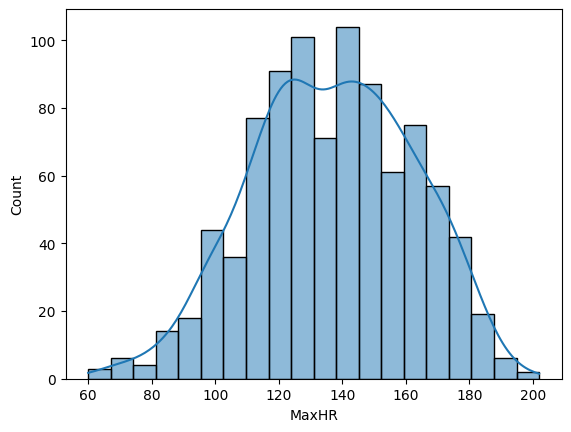

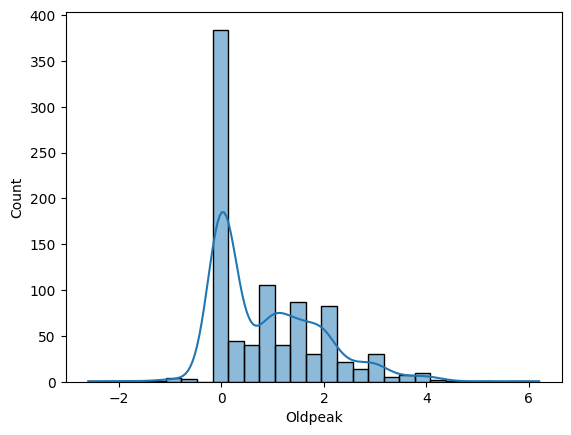

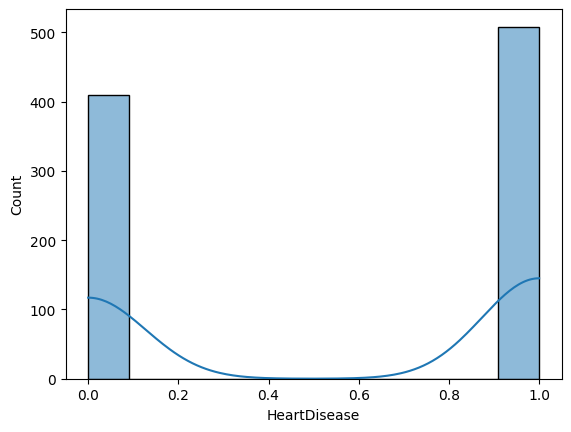

In [176]:
# FastingBS is class imbalanced

cols = df.select_dtypes(exclude='object')

for col in cols:
  sns.histplot(data=df,x=col,kde=True)
  plt.show()

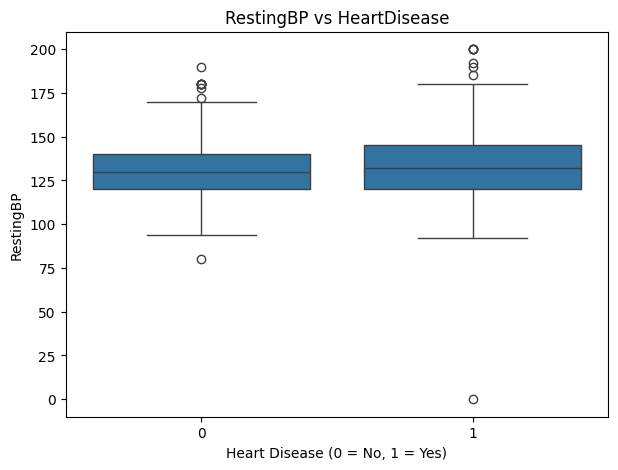

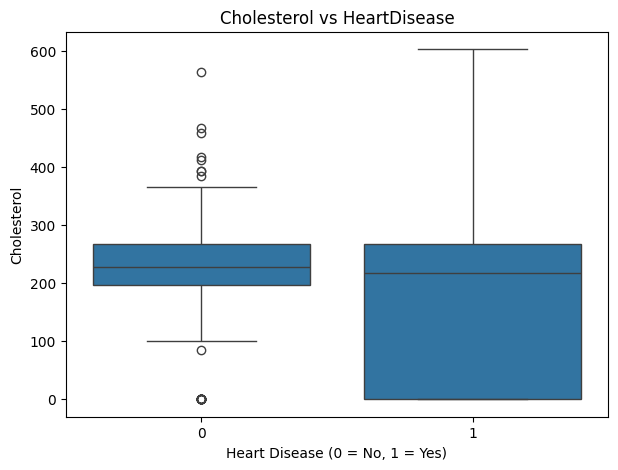

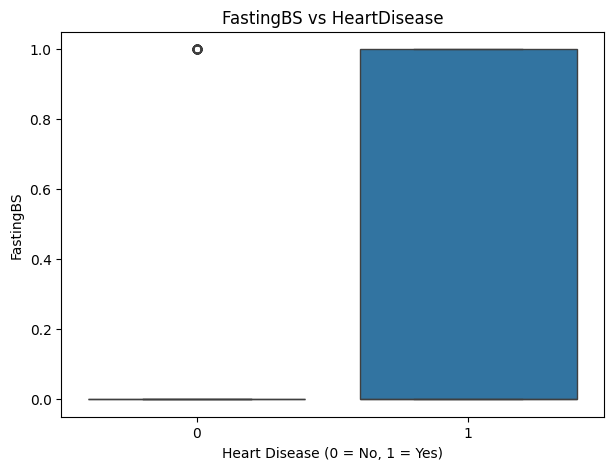

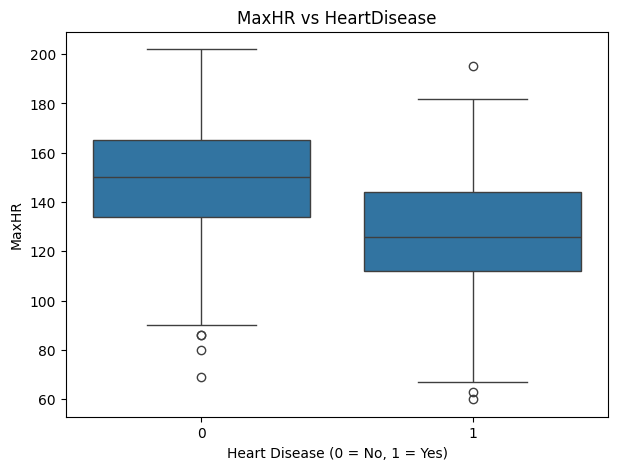

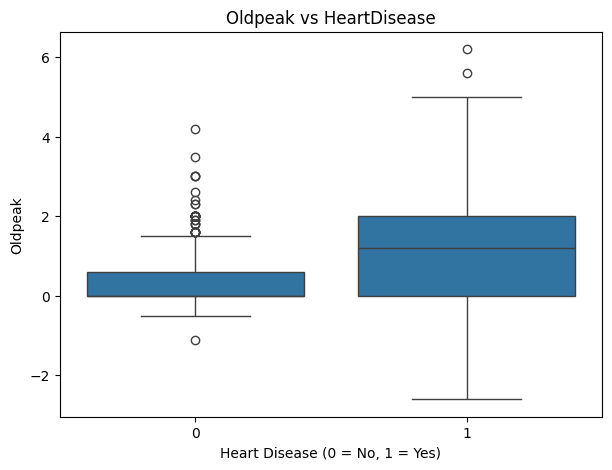

In [177]:
numeric_columns = [
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak"
]

for column in numeric_columns:
    plt.figure(figsize=(7, 5))

    sns.boxplot(
        data=df,
        x="HeartDisease",
        y=column
    )

    plt.title(f"{column} vs HeartDisease")
    plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
    plt.ylabel(column)

    plt.show()

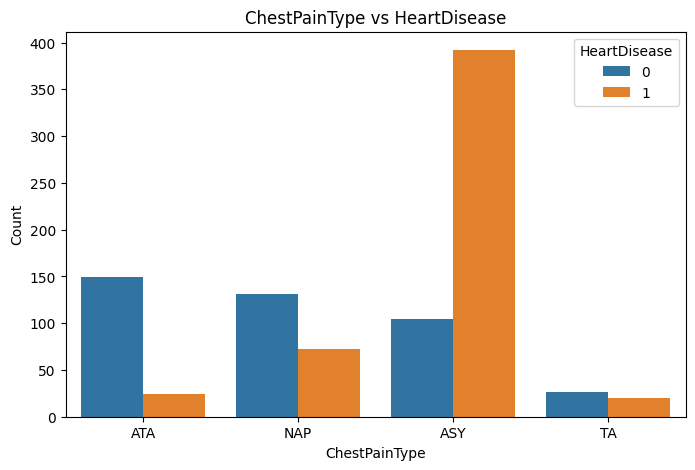

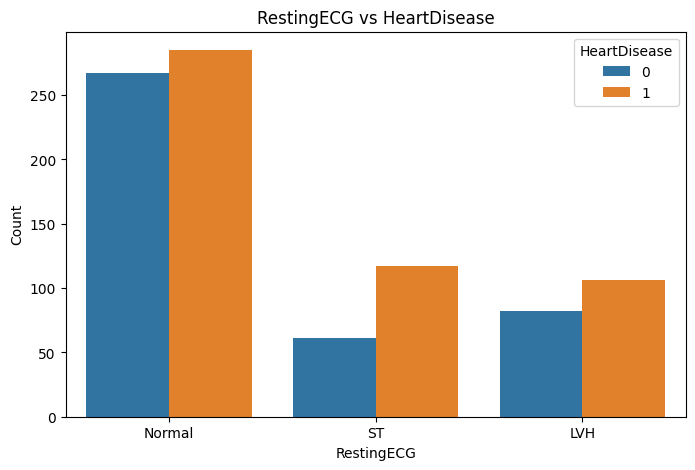

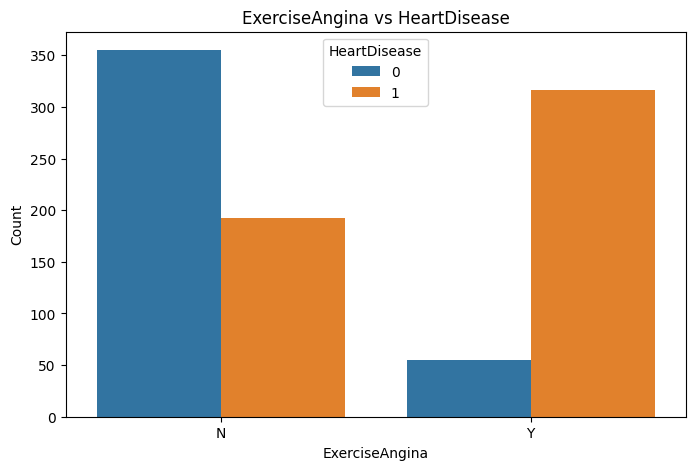

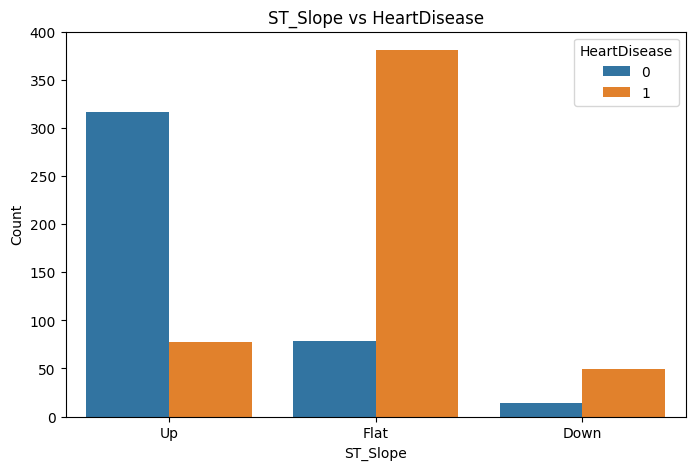

In [178]:
categorical_columns = [
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

for column in categorical_columns:
    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=column,
        hue="HeartDisease"
    )

    plt.title(f"{column} vs HeartDisease")
    plt.xlabel(column)
    plt.ylabel("Count")

    plt.show()

<Axes: xlabel='Age', ylabel='count'>

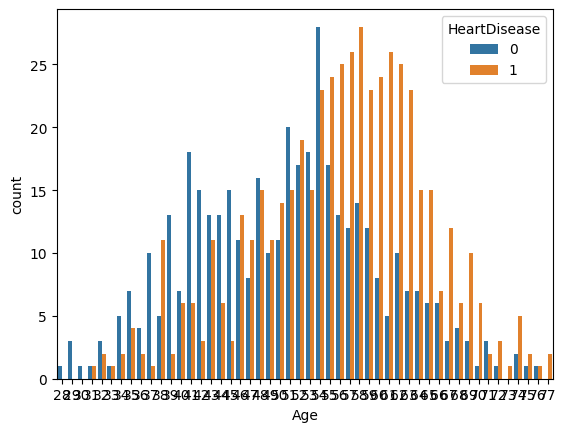

In [179]:
sns.countplot(data=df,x="Age",hue="HeartDisease")

**Data Preprocessing and Cleaning**

In [180]:
df_copy.head(2)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1


In [181]:
df_copy['Sex'].replace({'M':1,'F':0},inplace=True)

/tmp/ipykernel_3422/3305202934.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['Sex'].replace({'M':1,'F':0},inplace=True)
/tmp/ipykernel_3422/3305202934.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_copy['Sex'].replace({'M':1,'F':0},inplace=True)


In [182]:
df_copy.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [183]:
cols = ['Age','RestingBP','Cholesterol','MaxHR']
ss = StandardScaler()
df_copy[cols] = ss.fit_transform(df_copy[cols])

In [184]:
df_copy.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,-1.433140,1,ATA,0.410909,0.825070,0,Normal,1.382928,N,0.0,Up,0
1,-0.478484,0,NAP,1.491752,-0.171961,0,Normal,0.754157,N,1.0,Flat,1
2,-1.751359,1,ATA,-0.129513,0.770188,0,ST,-1.525138,N,0.0,Up,0
3,-0.584556,0,ASY,0.302825,0.139040,0,Normal,-1.132156,Y,1.5,Flat,1
4,0.051881,1,NAP,0.951331,-0.034755,0,Normal,-0.581981,N,0.0,Up,0


In [185]:
df_copy['ExerciseAngina'].unique()

array(['N', 'Y'], dtype=object)

In [186]:
df_copy['ExerciseAngina'] = df_copy['ExerciseAngina'].map({'Y':1,'N':0})

In [187]:
df['ST_Slope'].unique()

array(['Up', 'Flat', 'Down'], dtype=object)

In [188]:
cat_cols = ['ChestPainType','RestingECG','ST_Slope']
for col in cat_cols:
  df_copy = pd.concat([df_copy,pd.get_dummies(df[col],prefix=col)],axis=1)

In [189]:
df_copy.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,...,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,1,ATA,0.410909,0.825070,0,Normal,1.382928,0,0.0,...,False,True,False,False,False,True,False,False,False,True
1,-0.478484,0,NAP,1.491752,-0.171961,0,Normal,0.754157,0,1.0,...,False,False,True,False,False,True,False,False,True,False
2,-1.751359,1,ATA,-0.129513,0.770188,0,ST,-1.525138,0,0.0,...,False,True,False,False,False,False,True,False,False,True
3,-0.584556,0,ASY,0.302825,0.139040,0,Normal,-1.132156,1,1.5,...,True,False,False,False,False,True,False,False,True,False
4,0.051881,1,NAP,0.951331,-0.034755,0,Normal,-0.581981,0,0.0,...,False,False,True,False,False,True,False,False,False,True


In [190]:
df_copy.drop(cat_cols,axis=1,inplace=True)

In [191]:
df_copy.astype(int)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1
1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0
2,-1,1,0,0,0,-1,0,0,0,0,1,0,0,0,0,1,0,0,1
3,0,0,0,0,0,-1,1,1,1,1,0,0,0,0,1,0,0,1,0
4,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,0,1,-1,0,0,0,0,1,1,0,0,0,1,0,1,0,0,1,0
914,1,1,0,0,1,0,0,3,1,1,0,0,0,0,1,0,0,1,0
915,0,1,0,0,0,0,1,1,1,1,0,0,0,0,1,0,0,1,0
916,0,0,0,0,0,1,0,0,1,0,1,0,0,1,0,0,0,1,0


**Feature Selection**

In [192]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    float64
 1   Sex                918 non-null    int64  
 2   RestingBP          918 non-null    float64
 3   Cholesterol        918 non-null    float64
 4   FastingBS          918 non-null    int64  
 5   MaxHR              918 non-null    float64
 6   ExerciseAngina     918 non-null    int64  
 7   Oldpeak            918 non-null    float64
 8   HeartDisease       918 non-null    int64  
 9   ChestPainType_ASY  918 non-null    bool   
 10  ChestPainType_ATA  918 non-null    bool   
 11  ChestPainType_NAP  918 non-null    bool   
 12  ChestPainType_TA   918 non-null    bool   
 13  RestingECG_LVH     918 non-null    bool   
 14  RestingECG_Normal  918 non-null    bool   
 15  RestingECG_ST      918 non-null    bool   
 16  ST_Slope_Down      918 non

In [193]:
# Assuming 'df' is your DataFrame and 'Target' is the target column name
correlations = df_copy.corrwith(df_copy['HeartDisease'])
print(correlations)

Age                  0.282039
Sex                  0.305445
RestingBP            0.107589
Cholesterol         -0.232741
FastingBS            0.267291
MaxHR               -0.400421
ExerciseAngina       0.494282
Oldpeak              0.403951
HeartDisease         1.000000
ChestPainType_ASY    0.516716
ChestPainType_ATA   -0.401924
ChestPainType_NAP   -0.212964
ChestPainType_TA    -0.054790
RestingECG_LVH       0.010670
RestingECG_Normal   -0.091580
RestingECG_ST        0.102527
ST_Slope_Down        0.122527
ST_Slope_Flat        0.554134
ST_Slope_Up         -0.622164
dtype: float64


In [194]:
features_all = [
    "Age",
    "Sex",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "ExerciseAngina",
    "Oldpeak",
    "ChestPainType_ASY",
    "ChestPainType_ATA",
    "ChestPainType_NAP",
    "ChestPainType_TA",
    "RestingECG_LVH",
    "RestingECG_Normal",
    "RestingECG_ST",
    "ST_Slope_Down",
    "ST_Slope_Flat",
    "ST_Slope_Up"
]

In [195]:
X = df_copy[features_all]
y = df_copy['HeartDisease']

**Model Training**

In [196]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
confusion_matrix = confusion_matrix(y_test, y_pred)
classification_report = classification_report(y_test, y_pred)

In [197]:
print(f"accuracy_score: {accuracy}")
print(f"confusion_matrix: {confusion_matrix}")
print(f"classification_report: {classification_report}")

accuracy_score: 0.8804347826086957
confusion_matrix: [[68  9]
 [13 94]]
classification_report:               precision    recall  f1-score   support

           0       0.84      0.88      0.86        77
           1       0.91      0.88      0.90       107

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



In [198]:
scores = cross_val_score(
    rfc,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Scores:", scores)
print("Mean:", scores.mean())

Scores: [0.89673913 0.83152174 0.83695652 0.83606557 0.75956284]
Mean: 0.8321691613209788


**Multiple Algorithms**

In [199]:
algo = {
    "LogisticRegression": LogisticRegression(class_weight="balanced"),
    "RandomForestClassifier": RandomForestClassifier(class_weight="balanced"),
    "svc": SVC(class_weight="balanced"),
    "KNeighborsClassifier": KNeighborsClassifier(n_neighbors=15)
}

results = {}

for name, model in algo.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=2,
        scoring="accuracy"
    )

    results[name] = scores.mean()

    print(f"{name}:")
    print(f"  Scores: {scores}")
    print(f"  Mean: {scores.mean():.4f}")
    print()

LogisticRegression:
  Scores: [0.81917211 0.77777778]
  Mean: 0.7985

RandomForestClassifier:
  Scores: [0.85185185 0.77342048]
  Mean: 0.8126

svc:
  Scores: [0.86492375 0.77342048]
  Mean: 0.8192

KNeighborsClassifier:
  Scores: [0.85620915 0.81699346]
  Mean: 0.8366



**Increasing Accuracy by removing unwanted Features**

In [200]:
features_1 = [
    'Age',
    'Sex',
    'RestingECG_Normal',
    'Cholesterol',
    'FastingBS',
    'MaxHR',
    'ExerciseAngina',
    'Oldpeak',
    'ChestPainType_ASY',
    'ChestPainType_ATA',
    'ChestPainType_NAP',
    "ChestPainType_TA",
    "RestingECG_LVH",
    "RestingECG_Normal",
    "RestingECG_ST",
    "ST_Slope_Down",
    'ST_Slope_Flat',
    'ST_Slope_Up'
    ]

In [201]:
X = df_copy[features_1]
y = df_copy['HeartDisease']

In [202]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)

accuracy1 = accuracy_score(y_test, y_pred)
confusionmatrix = confusion_matrix(y_test, y_pred)
classificationreport = classification_report(y_test, y_pred)

TypeError: 'numpy.ndarray' object is not callable

In [ ]:
print(f"accuracy_score: {accuracy1}")
print(f"confusion_matrix: {confusionmatrix}")
print(f"classification_report: {classificationreport}")